# 06 — Integral windup

**The integrator does not know the engine has run out.**

Notebooks 03, 04 and 05 ran with the torque ceiling lifted — *assume for now an engine that
delivers whatever we ask*. Every gain in them is honest under that assumption, and the
assumption is what made the linear story tellable: a proportional term that scales, an
integrator that converges on the holding torque, a derivative that brakes on approach.

This notebook removes it. The engine has 150 N.m and not one more, and the loop from notebook
05 is about to ask for more than that for a sustained stretch — not as a transient spike during
a step, but for as long as the hill lasts.

The failure that follows is not a gain that was set too high. It is a controller carrying out
its own rule correctly while the plant it is attached to stops listening.

## Setup

Same bootstrap as every notebook in this set. The ceiling goes back where it belongs.

In [1]:
isdefined(Main, :Lecture01Support) || include("support.jl")

# Bound by hand rather than with `using`. If this kernel ever ran an earlier `include` of
# support.jl there are two copies of the module, every name both export is ambiguous, and no
# amount of re-running `using` resolves it. An explicit binding does, so this cell repairs a
# kernel in that state instead of needing it restarted. Editing support.jl still needs a
# restart, because the guard above deliberately will not load a second copy.
for n in names(Lecture01Support)
    n === :Lecture01Support && continue
    Core.eval(Main, :($n = Lecture01Support.$n))
end

In [2]:
setup()

Main.VehicleSystemsComponents

## 1. Actuators are not linear

Every block diagram so far has been a lie by omission. `u = k·e` says that doubling the error
doubles the command, and it keeps saying it at 300 N.m, at 1200 N.m, at 17 800 N.m — the
proportional term in notebook 03's `k = 890` run. Nothing in those equations knows the engine
tops out at 150.

Real actuators saturate. A valve is fully open, a rudder is hard over, an amplifier is at the
rail, an engine is at wide-open throttle. Past that point the actuator has one behavior: it
delivers its limit and ignores the rest of the command.

Two things are worth separating before we look at a plot.

- **Saturation on its own is not a fault.** A loop that asks for more than it can have, gets
  the limit, and approaches its setpoint more slowly than the linear design promised, has
  behaved sensibly. Notebook 08 ends on exactly that: three heuristic tunings, all commanding
  several times the engine, all still arriving.
- **What breaks is the integrator's bookkeeping.** The integral term's whole rule is *keep
  accumulating until the error is zero*. It reads the error. It does not read the delivered
  torque. So while the engine is pinned at its limit and the error refuses to close, the rule
  says the same thing it always says — accumulate — and the integrator climbs to a value that
  no longer corresponds to any torque the engine can produce.

The gap between what was commanded and what was delivered is the whole subject of this
notebook, and it opens the moment the command crosses 150 N.m.

### The models this runs

Four pieces, three of them already in the library.

`Lecture1.CruiseLoop` is unchanged from notebooks 03 to 05 — and it has always had a `grade`
input, tied to a constant zero by the flat-road step harness. This notebook is the first to
drive it. `Vehicle.GradeProfile` supplies the road: flat, then a climb of a given gradient
starting at `start_time`, and — with a finite `duration` — flat again afterwards. That second
flat stretch is where the damage shows, so the `duration` parameter exists for this notebook.
`Lecture1.CruiseClimb` ties the two together and `CruiseClimbTransient` is the analysis that
runs it.

The fourth is `Lecture1.ClampingPID`, built for section 4: a drop-in replacement for
`BlockComponents.Continuous.LimPID` that differs in the anti-windup scheme and nothing else.
`Lecture1.ClampingCruiseLoop` and `ClampingCruiseClimb` are the same loop and the same scenario
around it, and they keep the subcomponent names, so every signal path in this notebook reads
the same whichever controller is in the loop.

Sources: [`dyad/Lecture1/CruiseLoop.dyad`](../../dyad/Lecture1/CruiseLoop.dyad),
[`dyad/Lecture1/WindupClimb.dyad`](../../dyad/Lecture1/WindupClimb.dyad),
[`dyad/Lecture1/ClampingPID.dyad`](../../dyad/Lecture1/ClampingPID.dyad),
[`dyad/Vehicle/GradeProfile.dyad`](../../dyad/Vehicle/GradeProfile.dyad) and the force it
applies in [`dyad/Vehicle/GradeForce.dyad`](../../dyad/Vehicle/GradeForce.dyad).

In [3]:
show_dyad("GradeProfile")

GradeProfile — dyad/Vehicle/GradeProfile.dyad line 1 
 """
Road-grade scenario: flat, climb, then flat again.

The climb starts at `start_time` and lasts for `duration`. The default infinite duration retains
the original flat-to-sustained-climb behavior. A finite duration exposes the recovery transient
needed for the windup demonstration.
"""
component GradeProfile
 "Road gradient output, tan(alpha)"
 y = RealOutput() {^y}
 pulse = BlockComponents.Sources.Pulse(amplitude = gradient, offset = 0.0,
 start_time = start_time, duty_cycle = 1.0, period = duration) {^step}
 "Gradient of the climb, tan(alpha)"
 parameter gradient::Real = 0.10
 "Time at which the climb begins"
 parameter start_time::Time = 30.0
 "Climb duration; Inf retains a sustained climb"
 parameter duration::Time = Inf
relations
 connect(pulse.y, y) {^id3}
metadata {
 "_links": {
 "y": {
 "Dyad": {"placement": {"diagram": {"x1": 960, "x2": 1060, "y1": 450, "y2": 550}}}
 },
 "pulse": {
 "Dyad": {"placement": {"diagram": {"x1": 430, "x2": 530, "y1": 450, "y2": 550}}}
 },
 "id3": {"Dyad": {"edges": [{"S": 1, "M": [], "E": 2}], "path": {}}}
 }
}
end

## 2. The climb

The scenario is a car cruising at 130 km/h on the flat that meets a sustained 10% climb at
t = 30 s, and is still climbing long enough for the loop to settle into the saturated state.

The arithmetic is notebook 01's force balance with one term added, and it says the climb cannot
be held before anything is simulated:

| | |
|---|---|
| gravity along a 10% slope, `m·g·sin(atan 0.10)` | 1366 N |
| aerodynamic drag at 130 km/h | 493 N |
| rolling resistance, normal load shed by `cos α` | 164 N |
| **needed to hold 130 km/h uphill** | **2023 N** |
| **available, `T_max·i/r`** | **1935 N** |

The car is 88 N short. It cannot hold 130 km/h on that hill at any gain, with any controller,
and it heads instead for about 118 km/h — the speed at which the drag it sheds by slowing down
makes up the difference. It does not get all the way there. The car's own time constant is
about a minute, so 120 s of hill leaves it at a little over 119 and still falling, which is
worth noticing rather than smoothing over: the error is not merely large, it is still open when
the hill ends. That is the correct behavior of a car with a finite engine on a hill
that is too steep for it, and a lecture should say so before the plot arrives, so that nobody
reads the speed drop itself as the failure.

The failure is elsewhere. Watch the integrator while the speed sits some 11 km/h below its
setpoint.

                      flat, t = 30 s     top of the climb, t = 150 s
  speed [km/h]        129.96             119.05
  commanded [N.m]     51.07              6061.92
  delivered [N.m]     51.08              150.0
  integral k*I [N.m]  48.98              5448.28


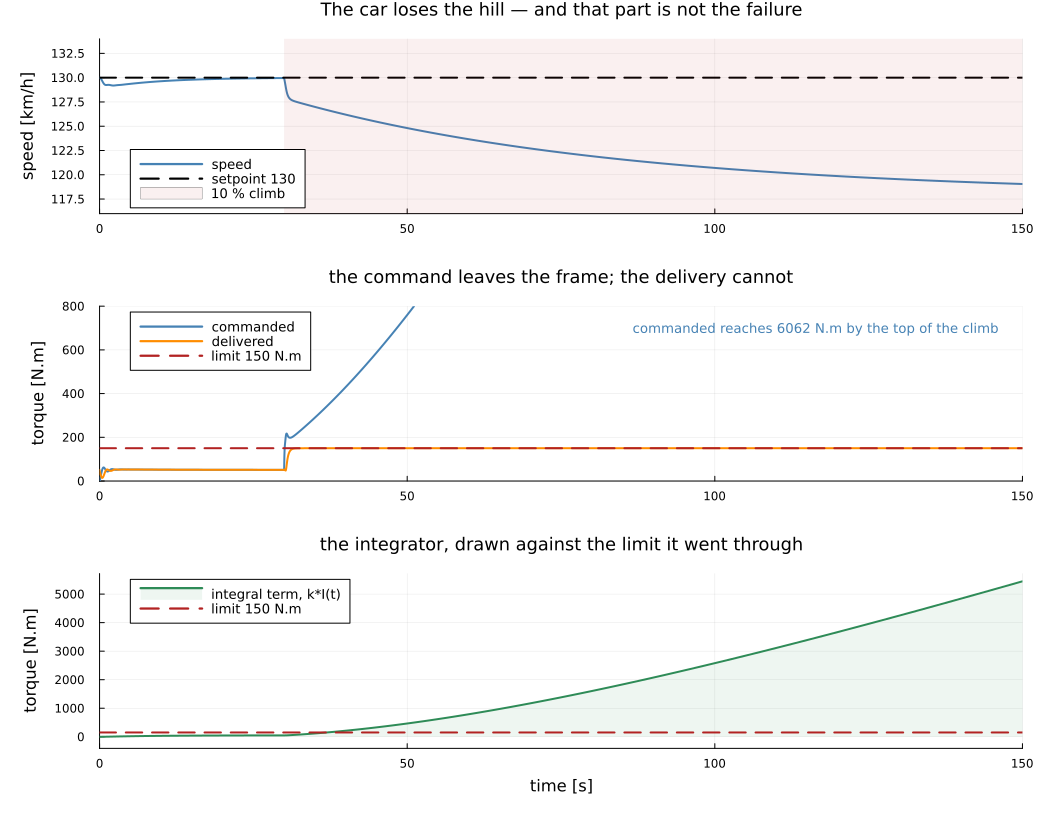

In [4]:
Scenarios = VehicleSystemsComponents.Lecture1

SPEED     = "loop.plant.v_kmh"
COMMAND   = "loop.controller.add_ff.y"      # the command, read before the controller's limiter
DELIVERED = "loop.plant.engine.limiter.y"   # what the engine put on the crankshaft
INTEGRAL  = "loop.controller.integrator.y"  # the integrator's state, before the gain k

SETPOINT    = 130.0     # km/h
GAIN        = 56.0      # N.m per km/h
T_I         = 10.0      # s
T_D         = 0.5       # s
CLIMB_START = 30.0      # s
CLIMB_END   = 150.0     # s
T_LIMIT     = CAR.T_max # N.m

# The back-calculation gain is 1/(k*Ni), so a huge Ni is how this model is asked for the
# controller that has no anti-windup at all. `LimPID` has no switch for it.
NO_ANTIWINDUP = 1.0e6

# Notebook 05's PID, gain for gain. Nothing about the controller changes in this notebook; the
# only thing that moved is that the engine's ceiling is back in place.
no_aw = Scenarios.CruiseClimbTransient(
    k = GAIN, Ti = T_I, Td = T_D, Ni = NO_ANTIWINDUP,
    start_time = CLIMB_START, duration = CLIMB_END - CLIMB_START, stop = 400.0)

at(run, path, t) = (s = solution_of(run); s(t, idxs = resolve(s, path)))

println("                      flat, t = 30 s     top of the climb, t = 150 s")
for (name, path, scale) in (("speed [km/h]     ", SPEED, 1.0),
                            ("commanded [N.m]  ", COMMAND, 1.0),
                            ("delivered [N.m]  ", DELIVERED, 1.0),
                            ("integral k*I [N.m]", INTEGRAL, GAIN))
    println("  ", rpad(name, 19),
            " ", rpad(round(scale * at(no_aw, path, CLIMB_START), digits = 2), 18),
            " ", round(scale * at(no_aw, path, CLIMB_END), digits = 2))
end

t, v = signal(no_aw, SPEED)
_, commanded = signal(no_aw, COMMAND)
_, delivered = signal(no_aw, DELIVERED)
_, integral  = signal(no_aw, INTEGRAL)

CLIMB_WINDOW = (0, CLIMB_END)

speed = plot(t, v; lw = 2, color = :steelblue, label = "speed", ylabel = "speed [km/h]",
             xlims = CLIMB_WINDOW, ylims = (116, 134), legend = :bottomleft,
             title = "The car loses the hill — and that part is not the failure")
hline!(speed, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "setpoint 130")
vspan!(speed, [CLIMB_START, CLIMB_END]; color = :firebrick, alpha = 0.07, label = "10 % climb")

# Deliberately scaled to the delivered torque rather than to the command: the command leaves
# the top of the frame within a few seconds of the climb starting, and a frame it fits inside
# would put the limit line and the delivered trace on top of each other at the bottom.
torque = plot(t, commanded; lw = 2, color = :steelblue, label = "commanded",
              ylabel = "torque [N.m]", xlims = CLIMB_WINDOW, ylims = (0, 800),
              legend = :topleft, title = "the command leaves the frame; the delivery cannot")
plot!(torque, t, delivered; lw = 2, color = :darkorange, label = "delivered")
hline!(torque, [T_LIMIT]; ls = :dash, lw = 2, color = :firebrick,
       label = "limit $(Int(T_LIMIT)) N.m")
annotate!(torque, CLIMB_END - 4, 700,
          text("commanded reaches $(round(Int, maximum(commanded))) N.m by the top of the climb",
               9, :right, :steelblue))

windup = plot(t, GAIN .* integral; lw = 2, color = :seagreen, fillrange = 0, fillalpha = 0.08,
              label = "integral term, k*I(t)", xlabel = "time [s]", ylabel = "torque [N.m]",
              xlims = CLIMB_WINDOW, legend = :topleft,
              title = "the integrator, drawn against the limit it went through")
hline!(windup, [T_LIMIT]; ls = :dash, lw = 2, color = :firebrick,
       label = "limit $(Int(T_LIMIT)) N.m")

climb_windup = plot(speed, torque, windup; layout = (3, 1), size = (1050, 820))
save_figure(climb_windup, "06-climb-windup")
climb_windup

## 3. Why the overshoot is coming

Nothing has gone wrong yet. The car is slower than asked, the engine is flat out, and a
passenger would report that the car is climbing a steep hill. The controller, meanwhile, is
accumulating.

Follow it in four steps, the same way notebook 04 followed the overshoot on a step.

1. **The error is stuck open.** About 11 km/h, and it will not close, because closing it needs
   torque that does not exist. The integrator's stopping condition is never met.
2. **So the sum grows, without limit and without effect.** Every second of a sustained error
   adds to it. The commanded torque climbs past 150, past 300, past whatever the hill and the
   gain between them produce — and the delivered torque does not move, because it has been at
   the limit since early in the climb. The command and the delivery have come apart, and
   nothing in the loop is measuring the gap.
3. **The road flattens, and the car starts accelerating.** The load that justified all that
   accumulation is gone in an instant. The error closes fast.
4. **But the command has to come back down before anything changes.** Reducing a command of
   400 N.m to 300 N.m changes the delivered torque by exactly nothing: both saturate to 150.
   The engine stays at full torque through the entire descent from 400 to 150, and the only
   thing that brings the sum down is *negative* error — the car being faster than its setpoint.

Step 4 is the one to sit with. The car must overshoot, and keep overshooting, for as long as it
takes to unwind everything the hill put into the integrator. The overshoot is not a symptom of
the windup. The overshoot **is** the unwinding, and its size is set by how long the hill lasted
rather than by any gain in the controller.

This is why windup is worse than it first looks. A tuning that is impeccable on a flat-road step
carries a fault that only appears after a long saturated stretch, and the longer the stretch the
worse the excursion — a controller whose error grows with the duration of the disturbance.

during the climb, the car falls to  119.05 km/h
after it, the car peaks at          179.8 km/h at t = 171.8 s
excess over the setpoint            49.8 km/h
back within 0.5 km/h of 130 after    68.3 s, at t = 218.3 s
the climb itself lasted             120 s


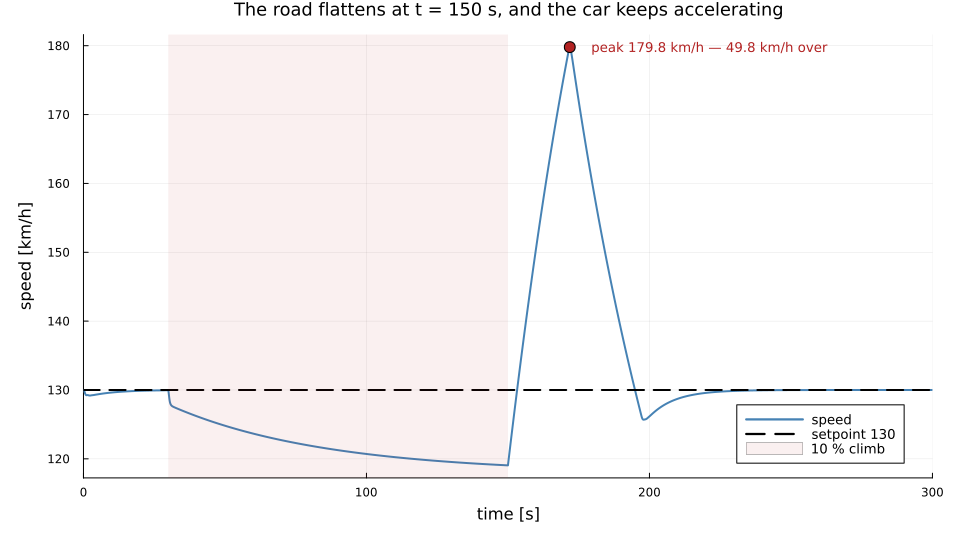

In [5]:
peak    = maximum(v)
t_peak  = t[argmax(v)]

# "Back to the setpoint" needs a tolerance band. The loop returns asymptotically and from
# above, so the last sample strictly greater than 130 is the last sample of the run whatever
# the controller did, which measures the window rather than the recovery.
BAND = 0.5      # km/h
unsettled = [i for i in eachindex(t) if t[i] > CLIMB_END && abs(v[i] - SETPOINT) > BAND]
recovered = t[last(unsettled)] - CLIMB_END

println("during the climb, the car falls to  ", round(minimum(v), digits = 2), " km/h")
println("after it, the car peaks at          ", round(peak, digits = 2), " km/h at t = ",
        round(t_peak, digits = 1), " s")
println("excess over the setpoint            ", round(peak - SETPOINT, digits = 2), " km/h")
println("back within ", BAND, " km/h of 130 after    ", round(recovered, digits = 1),
        " s, at t = ", round(CLIMB_END + recovered, digits = 1), " s")
println("the climb itself lasted             ", Int(CLIMB_END - CLIMB_START), " s")

plt = plot(t, v; lw = 2, color = :steelblue, label = "speed", xlabel = "time [s]",
           ylabel = "speed [km/h]", xlims = (0, 300), legend = :bottomright,
           title = "The road flattens at t = 150 s, and the car keeps accelerating")
hline!(plt, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "setpoint 130")
vspan!(plt, [CLIMB_START, CLIMB_END]; color = :firebrick, alpha = 0.07, label = "10 % climb")
scatter!(plt, [t_peak], [peak]; ms = 6, color = :firebrick, label = "")
annotate!(plt, t_peak + 8, peak,
          text("peak $(round(peak, digits = 1)) km/h — $(round(peak - SETPOINT, digits = 1)) km/h over",
               9, :left, :firebrick))
save_figure(plt, "06-overshoot")
plt

## 4. Clamping

The fix is to notice that the actuator has stopped listening, and stop integrating while it
has. Two conditions, both required:

1. **The output is saturating** — the command is at or past the limit.
2. **The error has the same sign as the output** — integrating further would push the command
   further into the limit.

When both hold, freeze the integrator. When either fails, resume.

The second condition is the one that is easy to drop and impossible to do without. Freezing on
saturation alone is a trap: the moment the road flattens, the loop needs the integrator to come
*down*, and a controller that is still saturated but now has negative error must be allowed to
integrate — otherwise the fix has produced a term that can never be reduced. Same-sign is what
makes the freeze one-directional: it blocks the accumulation that is going nowhere, and passes
the accumulation that is undoing it.

Clamping is popular because of what it does not require. There is no extra gain to choose and
no dynamics added; it is a switch on an existing path, and in a diagram it is one comparison and
an `if`. This is the method the source video teaches, and it is what the lecture demonstrates.

It is also the one block in this lecture that is not in a library: `Lecture1.ClampingPID` was
built for this notebook, and the whole of the rule above is four lines of nested `ifelse` in
its `with_I` branch. Run `show_dyad("ClampingPID")` to read the declaration here rather than
opening [the file](../../dyad/Lecture1/ClampingPID.dyad).

### Back-calculation, which is what `LimPID` already does

The Dyad block behind every controller in this lecture, `BlockComponents.Continuous.LimPID`,
ships an anti-windup scheme of its own — and it is not clamping. It is **back-calculation**, and
the difference is worth a minute in front of the room because the two produce visibly different
recoveries.

Instead of freezing the integrator, back-calculation *drives it back down*. It takes the
difference between what was commanded and what the actuator could deliver — the saturation
error, which is zero exactly when the actuator is listening — and feeds it
back into the integrator as a corrective input through a gain of `1/(k·Ni)`. The product
`Ni·Ti` is the time constant of that correction — it sets how fast the integrator is dragged
back toward a value consistent with what the actuator actually did. `Ni` defaults to 0.9 in
every loop in this lecture, and it is a number that has to be chosen.

The distinction in one line each:

- **Clamping** stops the integrator from getting worse. Nothing pulls it back, so on release it
  starts unwinding from wherever the freeze caught it.
- **Back-calculation** actively pulls the integrator toward the value that would have produced
  the delivered torque. By the time the actuator comes out of saturation, the integrator is
  already close to consistent with it.

Neither is uniformly better, and the comparison is worth making rather than asserting — which
is why the next cell makes it instead of telling you the answer. The usual expectation is that
back-calculation recovers better, because it does not wait for release to start correcting.
Clamping's compensating virtue is that it has nothing to tune and therefore cannot be tuned
wrong, where `Ni` set badly gives back-calculation its own failure modes: too short a tracking
time constant and the correction fights the controller, too long and it barely acts before the
actuator is free again.

Three controllers, then: none, clamping, back-calculation. Same car, same hill.

  anti-windup         peak speed    over setpoint    peak k*I     recovery
  none                179.8 km/h    49.8 km/h        5546.3 N.m   68.3 s
  clamping            130.17 km/h   0.17 km/h        62.2 N.m     3.5 s
  back-calculation    131.11 km/h   1.11 km/h        122.9 N.m    13.6 s


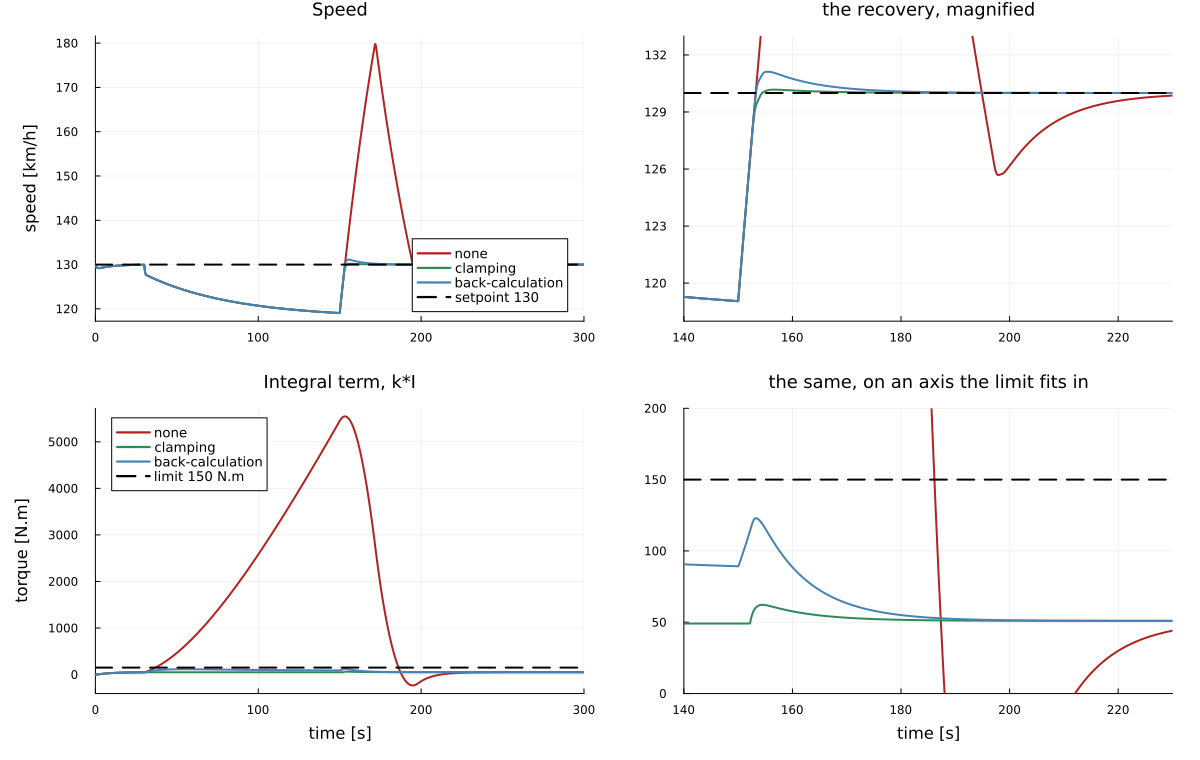

In [6]:
climb(; kwargs...) = (; k = GAIN, Ti = T_I, Td = T_D,
                      start_time = CLIMB_START, duration = CLIMB_END - CLIMB_START,
                      stop = 400.0, kwargs...)

backcalc = Scenarios.CruiseClimbTransient(; climb(Ni = 0.9)...)
clamped  = Scenarios.ClampingCruiseClimbTransient(; climb()...)

RUNS = (("none", no_aw, :firebrick),
        ("clamping", clamped, :seagreen),
        ("back-calculation", backcalc, :steelblue))

println("  anti-windup         peak speed    over setpoint    peak k*I     recovery")
for (name, run, _) in RUNS
    tt, vv = signal(run, SPEED)
    _, ii  = signal(run, INTEGRAL)
    off    = [i for i in eachindex(tt) if tt[i] > CLIMB_END && abs(vv[i] - SETPOINT) > BAND]
    back   = isempty(off) ? 0.0 : tt[last(off)] - CLIMB_END
    println("  ", rpad(name, 20),
            rpad(string(round(maximum(vv), digits = 2), " km/h"), 14),
            rpad(string(round(maximum(vv) - SETPOINT, digits = 2), " km/h"), 17),
            rpad(string(round(GAIN * maximum(ii), digits = 1), " N.m"), 13),
            round(back, digits = 1), " s")
end

speed_full = plot(; ylabel = "speed [km/h]", xlims = (0, 300), legend = :bottomright,
                  title = "Speed")
speed_zoom = plot(; xlims = (140, 230), ylims = (118, 133), legend = false,
                  title = "the recovery, magnified")
int_full = plot(; xlabel = "time [s]", ylabel = "torque [N.m]", xlims = (0, 300),
                legend = :topleft, title = "Integral term, k*I")
int_zoom = plot(; xlabel = "time [s]", xlims = (140, 230), ylims = (0, 200), legend = false,
                title = "the same, on an axis the limit fits in")

for (name, run, colour) in RUNS
    tt, vv = signal(run, SPEED)
    _, ii  = signal(run, INTEGRAL)
    for p in (speed_full, speed_zoom)
        plot!(p, tt, vv; lw = 2, color = colour, label = name)
    end
    for p in (int_full, int_zoom)
        plot!(p, tt, GAIN .* ii; lw = 2, color = colour, label = name)
    end
end

for p in (speed_full, speed_zoom)
    hline!(p, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "setpoint 130")
end
for p in (int_full, int_zoom)
    hline!(p, [T_LIMIT]; ls = :dash, lw = 2, color = :black, label = "limit $(Int(T_LIMIT)) N.m")
end

three_way = plot(speed_full, speed_zoom, int_full, int_zoom;
                 layout = (2, 2), size = (1200, 760))
save_figure(three_way, "06-three-way-antiwindup")
three_way

The top-left panel is the headline and the bottom-right is the explanation.

**Anti-windup of either kind removes the failure entirely.** Fifty km/h of overshoot becomes one
and a fraction, or a fifth of one. The car still loses the hill — all three traces sag to the
same 119 km/h, because no controller can make an engine that is flat out produce more — and
none of the three is at fault for that. What went away is the excursion afterwards, and with it
a recovery that took 68 s.

**The ordering of the two schemes is not the expected one.** Clamping overshoots by 0.17 km/h
and is back inside half a km/h of the setpoint 3.5 s after the road flattens; back-calculation
overshoots by 1.11 and takes 13.6 s. That is the opposite of the usual expectation, and the
reason is in the magnified integrator panel rather than in either method.

Back-calculation does not freeze the integrator, it *balances* it: the tracking term pulls down
in proportion to the saturation error while the error term pushes up, and the integrator settles
wherever those two cancel. On this hill that equilibrium is near 90 N.m — nearly twice the
50-odd N.m the flat road actually needs — so when the climb ends there is still a real surplus
to unwind. Clamping froze the integrator at very nearly the holding torque and had almost
nothing to give back.

The balance point is set by `Ni`. The tracking time constant is `Ni·Ti`, which is 9 s here
against a recovery that is over in a handful, so the correction acts slowly and settles high.
This is a statement about a parameter that was left at its library default, not a verdict on
back-calculation — and it is exactly the failure mode named above: `Ni` too long, and the
scheme barely acts before the actuator is free again. It is also the reason clamping is what
the lecture demonstrates. A method with no parameter cannot have its parameter left at the
wrong value.

## 5. Two limits, and only one of them is real

One practical note to close on, because it is the part that is got wrong in real systems by
people who have implemented anti-windup correctly.

There are two numbers in this loop that both look like *the torque limit*, and they are not the
same thing.

- **`T_max` is what the engine enforces.** It is a fact about the hardware, and it holds whether
  or not any software knows about it.
- **`y_max` is what the controller believes.** It is a constant in a program. It is what the
  saturation detector compares against, and therefore it is what decides when the integrator
  freezes.

`CruiseLoop` keeps them as separate parameters for exactly this reason, and the whole of
anti-windup rests on the relationship between them. The freeze fires when the command reaches
`y_max`. If `y_max` sits above what the engine actually delivers, then between the two there is
a band in which the engine is saturated, the error will not close, and the controller sees no
saturation at all — which is every condition of section 1, back again.

That band is where an ageing engine lives. An engine does not deliver 150 N.m. It delivers
150 N.m on a test bed, at sea level, at operating temperature, when it was new. Hot, worn, at
altitude, on poor fuel, it delivers less, and the nameplate the controller was programmed with
does not move with it.

The table below holds the engine fixed and varies only the number the controller believes.

In [7]:
# The engine's ceiling is held at its real value in every row but the last pair; the column
# that moves is `y_max`, the number the controller's saturation detector compares against.
println("  engine enforces   controller believes    lowest on the climb   peak after it   peak k*I")
for (enforced, believed, note) in ((150.0, 140.0, "margin below the ceiling"),
                                   (150.0, 150.0, "exactly at it"),
                                   (150.0, 200.0, "50 N.m of optimism"),
                                   (150.0, 300.0, "twice the ceiling"),
                                   (150.0, 1.0e6, "no clamp at all"),
                                   (138.0, 150.0, "a tired engine, clamp at the nameplate"))
    run = rerun(clamped, "T_max" => enforced, "y_max" => believed)
    tt, vv = signal(run, SPEED)
    _, ii  = signal(run, INTEGRAL)
    println("  ", rpad(string(round(Int, enforced), " N.m"), 18),
            rpad(believed > 1.0e5 ? "none" : string(round(Int, believed), " N.m"), 23),
            rpad(string(round(minimum(vv), digits = 2), " km/h"), 22),
            rpad(string(round(maximum(vv), digits = 2), " km/h"), 16),
            rpad(string(round(GAIN * maximum(ii), digits = 1), " N.m"), 12),
            note)
end

  engine enforces   controller believes    lowest on the climb   peak after it   peak k*I
  150 N.m           140 N.m                102.04 km/h           130.15 km/h     60.9 N.m    margin below the ceiling
  150 N.m           150 N.m                119.04 km/h           130.17 km/h     62.2 N.m    exactly at it
  150 N.m           200 N.m                119.09 km/h           130.55 km/h     85.8 N.m    50 N.m of optimism
  150 N.m           300 N.m                119.09 km/h           131.58 km/h     151.1 N.m   twice the ceiling
  150 N.m           none                   119.1 km/h            179.48 km/h     5431.3 N.m  no clamp at all
  138 N.m           150 N.m                98.48 km/h            130.16 km/h     61.6 N.m    a tired engine, clamp at the nameplate


Read the `peak after it` column downwards and the rule is not the one the folklore states.

**Below the ceiling and at it are both safe.** The freeze fires, the integrator never leaves the
neighbourhood of the holding torque, and the car comes back to 130 km/h without an excursion
worth naming.

**Above it, the damage is the size of the gap.** Fifty newton-metres of optimism buys half a
km/h of overshoot; twice the ceiling buys one and a half; and a controller with no output clamp
at all reproduces section 2's run to within a fraction of a km/h. That last row is worth a
second look, because it is not a hypothetical — it is what notebooks 03, 04 and 05 were running.
A clamping controller with `y_max` lifted has correct anti-windup logic that is never reached,
which is the most expensive kind of correct: it passes review, and it does nothing.

**And the margin is not free.** The first row clamps 10 N.m below an engine that has them, and
the car climbs the hill 17 km/h slower than it needed to — a much larger number than the 0.02
km/h of overshoot the margin bought back. On this car, at these gains, the prudent-sounding
advice is a bad trade, and the reason is visible in the last row of the table: a tired engine
moves the enforced ceiling by about 12 N.m, and 12 N.m of gap is worth almost nothing in
overshoot because the proportional term has already driven the command hundreds of N.m past
both numbers.

So the rule to carry out of here is the ordering, not the margin: **the clamp must not sit above
what the actuator enforces.** How far below to put it is a trade against authority, and it is a
trade you should make with the two numbers in front of you rather than by reflex. The systems
where the reflex earns its keep are the ones where the gap can be large — a valve that sticks, a
rudder meeting current, an amplifier sagging under load — and where the loop's own gain is low
enough that the command lives inside the gap instead of far above it.

## What this bought us

The loop now survives running out of actuator. That is a smaller claim than it sounds: nothing
here made the car able to climb the hill, and nothing made the speed drop go away. What went
away is the *second* failure — the one that arrives after the disturbance is over, that is
caused by the controller rather than the road, and that gets worse the longer the road stayed
steep.

Three things worth carrying out of this notebook.

- **Saturation is a modelling fact, not a tuning error.** It belongs in the model from the
  start, and the linear design is a design for a plant that does not exist.
- **The integrator's rule has an unstated assumption.** *Accumulate until the error is zero*
  assumes that accumulating more does something. Anti-windup, in any of its forms, is the
  business of detecting when it does not.
- **The command and the delivery are two different signals.** Every notebook before this one
  could plot one and mean the other. From here on they have to be plotted together.

**Notebook 07** goes after the derivative term the same way, with the same shape of argument: a
term whose rule is impeccable on an ideal signal, attached to a measurement that is not one.